# Analyse this naive k curve - flat overhead

- get average endpoints, average hashes, average reductions

## Imports

In [4]:
import numpy as np
import pandas as pd

t = 10000

## Get data 

In [5]:
## cherry m values
cherry_m_values = []

## cherry k values
cherry_k_values = []

# read in from each directory the m_values and append to cherry_m_values
for i in range(10):
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f'n-32/trial_{i}/m_values.npy')
    cherry_m_values.append(m_values)
    k_values = np.load(f'n-32/trial_{i}/kis.npy')
    cherry_k_values.append(k_values)


## vanilla m values
vanilla_m_values = []
for i in range(2):
    m_values = np.load(f'../vanilla/n-32/trial_{i}/m_values.npy')
    vanilla_m_values.append(m_values)

In [6]:
# create dataframe with columns "table", "avg. endpoints", "avg. hashes", "avg. reductions"
df = pd.DataFrame(columns=["table", "avg. endpoints", "avg. hashes", "avg. reductions"])

## get cherry data first
cherry_avg_mt = np.mean([cherry[-1] for cherry in cherry_m_values])
cherry_avg_hashes = np.mean([np.sum(cherry[:-1]) for cherry in cherry_m_values])
# cherry_avg_reductions = np.mean([np.sum(cherry[:-1] * 100) for cherry in cherry_m_values])  # since k_i = 100


cherry_reductions = []
for i in range(10):
    ch_red = []
    for k in range (t):
        ch_red.append(cherry_k_values[i][k] * cherry_m_values[i][k])
    cherry_reductions.append(np.sum(ch_red))

cherry_avg_reductions = np.mean(cherry_reductions)

# df = df.concat({"table": "cherry", "avg. endpoints": cherry_avg_mt, "avg. hashes": cherry_avg_hashes, "avg. reductions": cherry_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "cherry", 
    "avg. endpoints": cherry_avg_mt, 
    "avg. hashes": cherry_avg_hashes, 
    "avg. reductions": cherry_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

## get vanilla data
vanilla_avg_mt = np.mean([vanilla[-1] for vanilla in vanilla_m_values])
vanilla_avg_hashes = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])
vanilla_avg_reductions = np.mean([np.sum(vanilla[:-1]) for vanilla in vanilla_m_values])  # since k_i = 1
# df = df.append({"table": "vanilla", "avg. endpoints": vanilla_avg_mt, "avg. hashes": vanilla_avg_hashes, "avg. reductions": vanilla_avg_reductions}, ignore_index=True)
new_row = pd.DataFrame([{
    "table": "vanilla", 
    "avg. endpoints": vanilla_avg_mt, 
    "avg. hashes": vanilla_avg_hashes, 
    "avg. reductions": vanilla_avg_reductions
}])

df = pd.concat([df, new_row], ignore_index=True)

display(df)

C:\Users\psymf9\AppData\Local\Temp\ipykernel_2184\2932210308.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


,table,avg. endpoints,avg. hashes,avg. reductions
0,cherry,824683.8,1.490189e+10,5.372939e+12
1,vanilla,686421.0,1.382320e+10,1.382320e+10


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


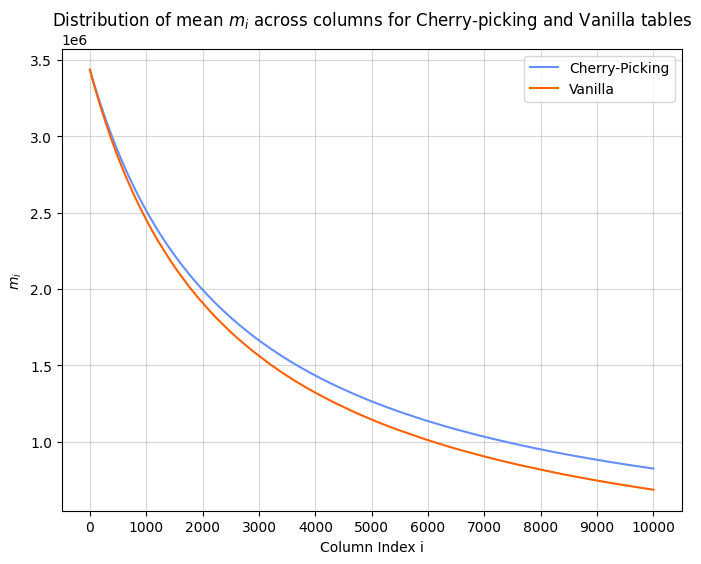

In [7]:
## Plot m_values for cherry and vanilla
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(8, 6))

x_indicies = np.arange(t + 1)  # x values from 0 to 256
cherry_m_values_array = np.array(np.mean(cherry_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, cherry_m_values_array, color='#648fff', label="Cherry-Picking", markersize=5)

vanilla_m_values_array = np.array(np.mean(vanilla_m_values, axis=0))  # take mean across trials for each index
plt.plot(x_indicies, vanilla_m_values_array, color='#FE6100', label="Vanilla", markersize=5)

ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)



plt.xlabel("Column Index i")
plt.ylabel(r"$m_i$")
plt.title(r"Distribution of mean $m_i$ across columns for Cherry-picking and Vanilla tables")
plt.legend()
# plt.grid()
# save as svg
plt.savefig(f"m_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')
plt.show()

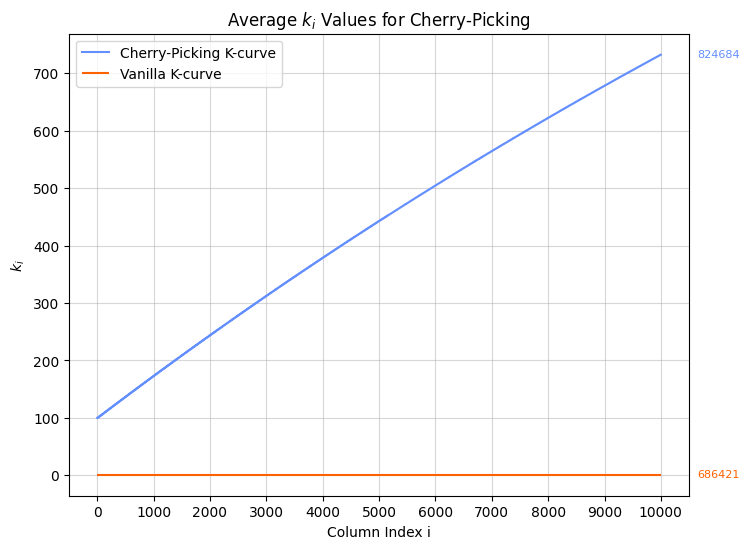

<Figure size 640x480 with 0 Axes>

In [8]:
# ## Plot k_i values for cherry-picking - plot the mean of each index across trials
# plt.figure(figsize=(8, 6))

# x_indicies = np.arange(t)  # x values from 0 to 255
# cherry_k_values_array = np.array(np.mean(cherry_k_values, axis=0))
# plt.plot(x_indicies, cherry_k_values_array, label='Cherry-Picking', color='#648fff')


# # annotate the end of the line with the average m_t value
# ax.annotate(f'avg. $m_t$ = {cherry_avg_mt:.2f}', xy=(t-1, cherry_k_values_array[-1]), xytext=(t-50, cherry_k_values_array[-1]+5),
#             arrowprops=dict(facecolor='#648fff', shrink=0.05), fontsize=10)

# # draw a horizontal line at y=1 to indicate the k_i value for vanilla
# plt.axhline(y=1, linestyle='--', label='Vanilla $k_i$', color='#FE6100')

# # annonate the end of the line with average vanilla m_t value
# ax.annotate(f'avg. $m_t$ = {vanilla_avg_mt:.2f}', xy=(t-1, 1), xytext=(t-50, 6),
#             arrowprops=dict(facecolor='#FE6100', shrink=0.05), fontsize=10)

# # set x-axis ticks to be every 20 units
# ax = plt.gca()
# ax.xaxis.set_major_locator(MultipleLocator(20))
# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
# plt.grid(visible=True, which='both', axis='both', alpha = 0.5)


# ax.set_xlabel('Column Index i')
# ax.set_ylabel(r'$k_i$')
# ax.set_title(r'Average $k_i$ Values for Cherry-Picking')
# ax.legend()
# plt.show()

## Plot k_i values for cherry-picking - plot the mean of each index across trials
plt.figure(figsize=(8, 6))

x_indicies = np.arange(t)  # x values from 0 to 255
cherry_k_values_array = np.array(np.mean(cherry_k_values, axis=0))
plt.plot(x_indicies, cherry_k_values_array, label='Cherry-Picking K-curve', color='#648fff')


# annotate the end of the line with the average m_t value
# ax.annotate(f'avg. $m_t$ = {cherry_avg_mt:.2f}', xy=(t-1, cherry_k_values_array[-1]), xytext=(t-50, cherry_k_values_array[-1]+5),
#             arrowprops=dict(facecolor='#648fff', shrink=0.05), fontsize=10)
y = cherry_k_values_array[-1]
plt.annotate(round(cherry_avg_mt),
             xy = (t+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#648fff',
             textcoords = 'offset points',
             size=8,
             va='center')

# draw a horizontal line at y=1 to indicate the k_i value for vanilla - start from x = 0
# plt.axhline(y=1, linestyle='--', label='Vanilla $k_i$', color='#FE6100')
max_x = t
plt.hlines(
    y=1, 
    xmin=0, 
    xmax=max_x,  
    label='Vanilla K-curve', 
    color='#FE6100'
)

# annonate the end of the line with average vanilla m_t value
# ax.annotate(f'avg. $m_t$ = {vanilla_avg_mt:.2f}', xy=(t-1, 1), xytext=(t-10, 6),
#             arrowprops=dict(facecolor='#FE6100', shrink=0.05), fontsize=10)
y = 1
plt.annotate(round(vanilla_avg_mt),
             xy = (t+500, y),   # place text outside box in line with end of curve
             xytext = (6, 0),
             color = '#FE6100',
             textcoords = 'offset points',
             size=8,
             va='center')

# set x-axis ticks to be every 20 units
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x)}'))
plt.grid(visible=True, which='both', axis='both', alpha = 0.5)


ax.set_xlabel('Column Index i')
ax.set_ylabel(r'$k_i$')
ax.set_title(r'Average $k_i$ Values for Cherry-Picking')
ax.legend()
plt.show()
# save as eps
plt.savefig(f"k_values_distribution_t_{t}.eps", format='eps', bbox_inches='tight')

In [9]:
# save k values in a file
np.save(f"cherry_k_values_t_{t}.npy", cherry_k_values_array)